# VULCAN — Vacuum Ultraviolet Light Characterisation At Nikhef

Detector materials for liquid argon experiments must be characterised at vacuum ultraviolet (VUV) wavelengths — down to 128 nm, the scintillation wavelength of argon — where standard spectrophotometers have no sensitivity and air itself absorbs the light. VULCAN is a custom VUV reflectometry setup built at Nikhef to fill this gap.

The setup consists of a vacuum chamber, a deuterium lamp as the VUV light source, a monochromator for wavelength selection (122–230 nm), and a three-channel SiPM-based readout. Samples are mounted on a rotating stage; reflectivity is extracted by sweeping the angle and fitting the angular distribution of reflected light with a Gaussian. Results are normalised against a known reflectance standard and corrected for the wavelength-dependent grating efficiency, lamp spectrum, and SiPM quantum efficiency.

This notebook presents the analysis pipeline applied to an aluminium sample considered for the PCB support structure in a liquid argon detector. Reflectivity measurements at 122, 128, 138, and 175 nm provide essential data for accurate detector simulations for experiments such as DUNE and DarkSide.

> **Note:** Raw waveform data lives on the Nikhef computing cluster. This notebook is shown with pre-computed outputs.

## 1. Setup and Imports

Raw waveform data is read using `strax`, the data processing framework used by XENONnT and related experiments. SiPM pulse finding and SPE calibration are implemented locally on top of the raw records.

In [ ]:
import strax
import time
import numpy as np
import glob
import os
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import poisson
from scipy.special import erf
from scipy.interpolate import interp1d
import pickle
import pandas as pd

plt.style.use('sty.mplstyle')
plt.rcParams['text.usetex'] = False

## 2. Fitting Functions

Model functions used throughout the analysis for SPE spectrum fitting, angular sweep fitting, and reflectivity extraction.

In [ ]:
def line_fit(x, a, b):
    """Straight line — used for PMT gain drift monitoring over runs."""
    return [k * a + b for k in x]


def gaussian(x, a, b, c):
    """Simple Gaussian — used for fitting the angular sweep light distribution."""
    return [a * np.exp(-(x[k] - b)**2 / (2 * c**2)) for k in range(len(x))]


def fit_gaussian_constant(x, a, b, c, d):
    """Gaussian + constant background."""
    return [a * np.exp(-(x[k] - b)**2 / (2 * c**2)) + d for k in range(len(x))]


def fit_gaussian_line(x, a, b, c, d, e):
    """Gaussian + linear background — used for muon charge spectrum fitting."""
    return [a * np.exp(-(x[k] - b)**2 / (2 * c**2)) + d * x[k] + e for k in range(len(x))]


def fit_double_gaussian(x, a, b, c, f, g, h, d):
    """Double Gaussian + constant — used where two reflectivity peaks overlap."""
    return [a * np.exp(-(x[k] - b)**2 / (2 * c**2)) +
            f * np.exp(-(x[k] - g)**2 / (2 * h**2)) + d
            for k in range(len(x))]


def constant(x, d):
    """Flat line — used for baseline estimation."""
    return [d for _ in x]


def gaussian_area_error(A, sigma, dA, dsigma):
    """
    Propagate uncertainty on the area of a Gaussian peak.
    Area = A * sigma * sqrt(2*pi), so errors on A and sigma both contribute.
    """
    factor = np.sqrt(2 * np.pi)
    return np.sqrt((sigma * factor * dA)**2 + (A * factor * dsigma)**2)


def fit_all_channels_shared_width(xdata, *params):
    """
    Fit Gaussian peaks for all three SiPM channels simultaneously,
    constraining them to share a common width. This reduces free parameters
    and improves stability when the angular sweep range is narrow.

    xdata : (N, 2) array — column 0 is angle, column 1 is channel index (0,1,2)
    params : [A0, mu0, d0, A1, mu1, d1, A2, mu2, d2, sigma_shared]
    """
    x  = xdata[:, 0]
    ch = xdata[:, 1].astype(int)
    yfit = np.zeros_like(x)

    for i in range(3):
        A  = params[i * 3]
        mu = params[i * 3 + 1]
        d  = params[i * 3 + 2]
        mask = ch == i
        yfit[mask] = A * np.exp(-(x[mask] - mu)**2 / (2 * params[-1]**2)) + d

    return yfit

## 3. Waveform Processing and SPE Calibration

Raw SiPM waveforms are read from disk using `strax` and processed trace-by-trace. The processing chain has three steps:

**Baseline estimation:** For each trace, a channel-specific ADC window known to contain only baseline is identified. The mean and RMS of this window give the baseline level and noise floor.

**Peak finding:** Peaks above a threshold of 50 ADC are identified using `scipy.find_peaks`. Isolated peaks separated by >300 samples on each side are flagged as single photoelectron (SPE) candidates — these are photons arriving when no other activity is present, giving a clean SPE signal.

**SPE calibration:** The charge distribution (pulse area in ADC·ns) is histogrammed across all traces and fit with a multi-Gaussian model — one peak per photoelectron number. The distance between the pedestal and the first PE peak gives the SPE gain in ADC·ns, which converts all subsequent light measurements from ADC units to photoelectrons.

The SPE gain is monitored run-by-run to track PMT stability over the measurement campaign. The per-run gain values are stored in `run_results` and loaded in subsequent blocks.

> **Note:** Raw waveform processing runs on the Nikhef cluster. Processed results are loaded from store in the blocks below.

In [ ]:
def multi_gaussian_fit(x, *params):
    """
    Sum of N Gaussians with linearly growing width — models the SPE charge spectrum.
    Each successive PE peak is broader due to the convolution of single-PE fluctuations.

    params: [ctr_0, spacing, width_single, width_growth, amp_0, amp_1, ..., amp_N]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params) - 4):
        ctr = params[0] + i * np.abs(params[1])
        wid = np.sqrt(params[2]**2 + i * params[3]**2)
        amp = np.abs(params[4 + i])
        y  += amp * np.exp(-((x - ctr) / (2 * wid))**2)
    return y


def baseline_finder(data, channel):
    """
    Estimate the baseline for a single trace by selecting samples
    within a channel-specific ADC window known to be signal-free.
    Returns the mean and RMS of the baseline samples.
    """
    boundary = [[1670, 1687], [1585, 1605], [1635, 1655]]
    data  = np.array(data)
    mask  = (data > boundary[channel][0]) & (data < boundary[channel][1])
    return np.mean(data[mask]), np.std(data[mask])


def peak_finder(trace, spe_peak):
    """
    Scan a baseline-subtracted trace for peaks above threshold.
    For each peak, record start, centre, end, integrated area, and
    whether it coincides with an isolated SPE candidate.
    Also records noise samples between peaks for use in SPE spectrum fitting.
    """
    threshold     = 50
    threshold_low = 2
    last_peak_end = 0
    pulses, noises = [], []

    j = 0
    while j < len(trace):
        if j >= last_peak_end and trace[j] > threshold:
            peak_start = next((j - k for k in range(1, 100)
                               if trace[j - k] <= threshold_low and j - k > -1), j)
            peak_index, max_val = j, trace[j]
            for k in range(j, len(trace)):
                if trace[k] > max_val:
                    peak_index, max_val = k, trace[k]
                if trace[k] <= threshold_low:
                    break
            peak_end = next((k + dk for dk in range(1, 20)
                             if k + dk < len(trace) and trace[k + dk] <= threshold_low), k)

            if peak_start - last_peak_end > 500:
                for s in range(last_peak_end + 90, peak_start - 90, 90):
                    noises.append(np.sum(trace[s:s + 90]))

            last_peak_end = peak_end
            pulses.append([peak_start, peak_index, peak_end,
                           np.sum(trace[peak_start:peak_end]),
                           int(peak_index in spe_peak)])
        j += 1

    return pulses, noises


def analyze(records, start=0, end=1000):
    """
    Process strax records for all three SiPM channels.
    For each trace: estimate baseline, find peaks, accumulate
    pulse areas and noise samples for SPE spectrum fitting.

    Returns channel_data dict keyed by channel index,
    each entry containing (all_pulses, all_noises).
    """
    channel_data = {}

    for channel in [0, 1, 2]:
        all_pulses, all_noises = [], []
        apndata = []

        for i in range(start, min(end, len(records))):
            record = records[i]
            if record[3] == channel:
                apndata.extend([x for x in record[7] if x != 0])
                if np.min(record[7]) == 0:
                    baseline, _ = baseline_finder(apndata, channel)
                    trace       = np.array(apndata) - baseline

                    small_peaks, _ = find_peaks(trace, prominence=50, height=50, width=10)
                    spe_peak = [small_peaks[l] for l in range(1, len(small_peaks) - 1)
                                if small_peaks[l] - small_peaks[l-1] > 300
                                and small_peaks[l+1] - small_peaks[l] > 400]

                    pulses, noises = peak_finder(trace, spe_peak)
                    all_pulses.append(pulses)
                    all_noises.extend(noises)
                    apndata = []

        channel_data[channel] = (all_pulses, all_noises)

    return channel_data

## 4. PMT Gain Stability

Before extracting reflectivity, the gain of each SiPM channel must be verified to be stable across the measurement campaign. A drifting gain would directly bias the light yield estimate and therefore the reflectivity.

For each run, the SPE charge spectrum is fit with `multi_gaussian_fit` to extract the gain in ADC·ns. The gain is plotted vs run index for all three channels. A step change is visible around run 1071, corresponding to a high-voltage adjustment made during the campaign — the two periods are treated separately in the analysis.

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Palatino
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Palatino
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Palatino


2964.7762078869105 3022.0412522248066
[3.51331652e-02 2.95742042e+03]
3405.623519376051 3524.700848981308
[7.55262120e-01 3.37094627e+03]
missing
missing
2837.8948509821707 2884.113657954948
[6.34710961e-02 2.83187289e+03]


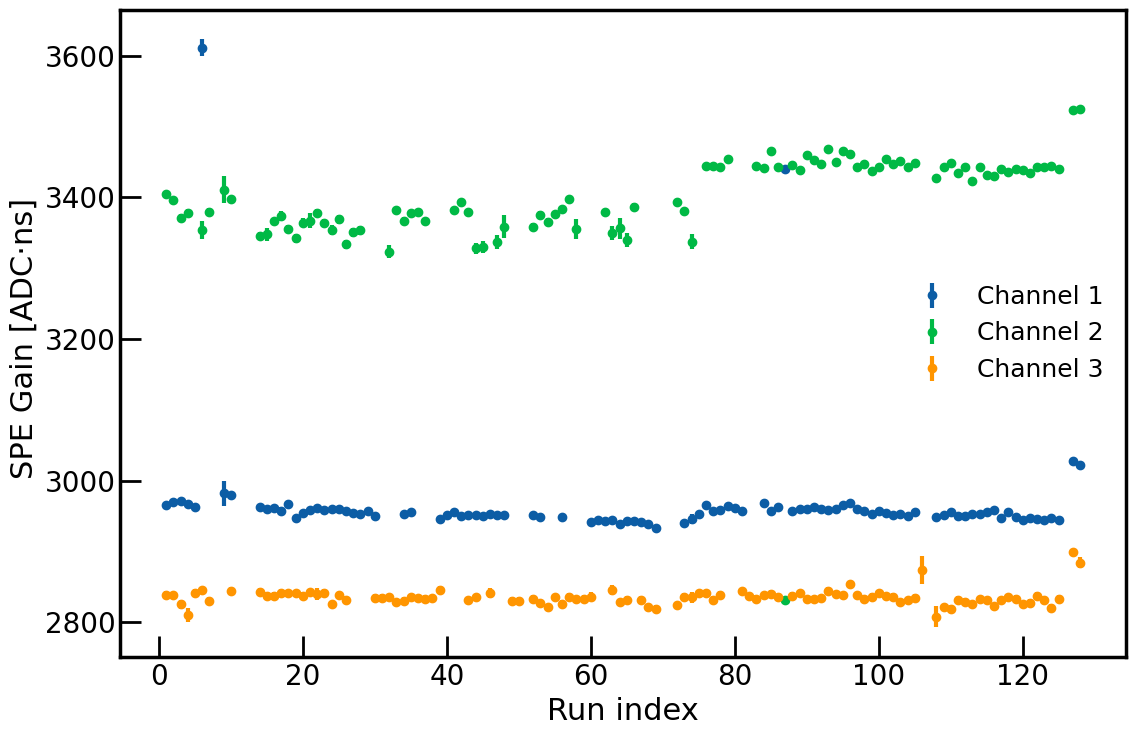

In [ ]:
%store -r run_results

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(12, 8))
for k in range(3):
    spe, spe_err, index = [], [], []
    counter = 0
    for key in range(998, 1200):
        if key in run_results:
            counter += 1
            try:
                if run_results[key][0][k][0] and run_results[key][0][k][1] < 20:
                    index.append(counter)
                    spe.append(run_results[key][0][k][0])
                    spe_err.append(run_results[key][0][k][1])
            except:
                pass
    plt.errorbar(index, spe, spe_err, fmt='o', color=colors[k], label=f'Channel {k+1}')
    popt, _ = curve_fit(line_fit, index, spe, p0=[1, 1], sigma=spe_err)

plt.xlabel('Run index', fontsize=22)
plt.ylabel('SPE Gain [ADC·ns]', fontsize=22)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('gain_evolution.pdf')
plt.show()

Run <1071, Channel 1 fit params: [-3.92018514e-01  2.96764087e+03]
Run <1071, Channel 2 fit params: [-5.66244301e-02  3.38086721e+03]
missing
Run <1071, Channel 3 fit params: [-1.70235478e-01  2.84008479e+03]


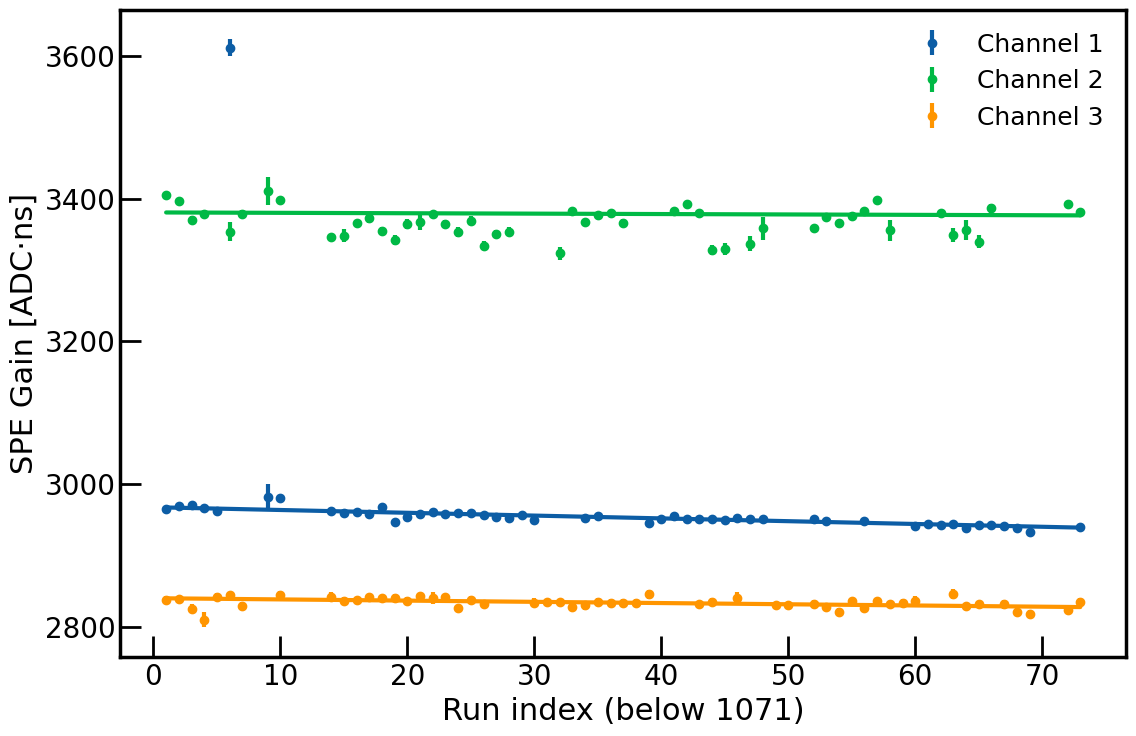

Run >=1071, Channel 1 fit params: [-6.43586261e-01  2.98495508e+03]
Run >=1071, Channel 2 fit params: [5.01099480e-01 3.43470676e+03]
missing
Run >=1071, Channel 3 fit params: [3.04567882e-01 2.83007061e+03]


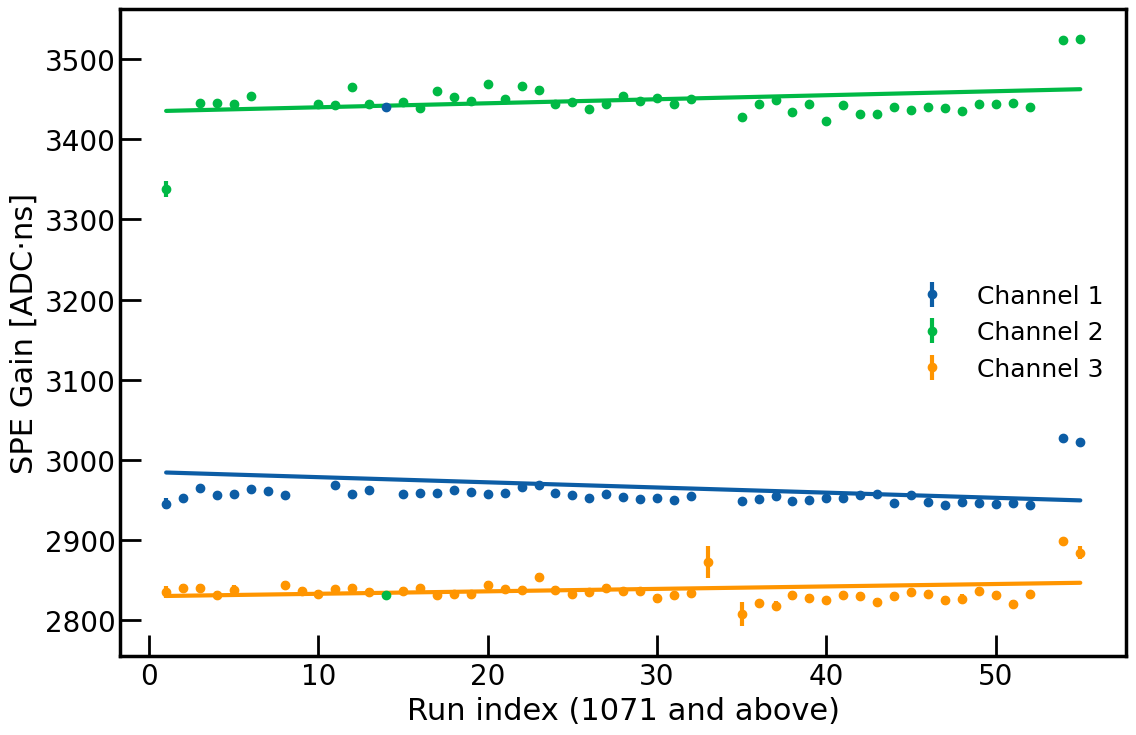

In [ ]:
%store -r v1_results  #same as run_results, just renamed for storage
run_results = v1_results

# Runs before HV adjustment
plt.figure(figsize=(12, 8))
for k in range(3):
    spe, spe_err, index = [], [], []
    counter = 0
    for key in range(998, 1200):
        if key in run_results and key < 1071:
            counter += 1
            try:
                if run_results[key][0] and run_results[key][0][k][0] and run_results[key][0][k][1] < 20:
                    index.append(counter)
                    spe.append(run_results[key][0][k][0])
                    spe_err.append(run_results[key][0][k][1])
            except:
                pass
    plt.errorbar(index, spe, spe_err, fmt='o', color=colors[k], label=f'Channel {k+1}')
    if len(index) >= 2:
        popt, _ = curve_fit(line_fit, index, spe, p0=[1, 1], sigma=spe_err)
        plt.plot(index, line_fit(np.array(index), *popt), color=colors[k])

plt.xlabel('Run index (below 1071)', fontsize=22)
plt.ylabel('SPE Gain [ADC·ns]', fontsize=22)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('gain_evolution_below_1071.pdf')
plt.show()

# Runs after HV adjustment
plt.figure(figsize=(12, 8))
for k in range(3):
    spe, spe_err, index = [], [], []
    counter = 0
    for key in range(998, 1130):
        if key in run_results and key >= 1071:
            counter += 1
            try:
                if run_results[key][0] and run_results[key][0][k][0] and run_results[key][0][k][1] < 20:
                    index.append(counter)
                    spe.append(run_results[key][0][k][0])
                    spe_err.append(run_results[key][0][k][1])
            except:
                pass
    plt.errorbar(index, spe, spe_err, fmt='o', color=colors[k], label=f'Channel {k+1}')
    if len(index) >= 2:
        popt, _ = curve_fit(line_fit, index, spe, p0=[1, 1], sigma=spe_err)
        plt.plot(index, line_fit(np.array(index), *popt), color=colors[k])

plt.xlabel('Run index (1071 and above)', fontsize=22)
plt.ylabel('SPE Gain [ADC·ns]', fontsize=22)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig('gain_evolution_above_1071.pdf')
plt.show()

## 5. Angular Sweep and Light Yield vs Wavelength

Reflectivity is measured by sweeping the sample angle in steps of 0.2° and recording the light intensity on each SiPM channel. At the specular reflection angle, the light intensity peaks — the area under this angular distribution is proportional to the total reflected flux.

For each wavelength setting, all three SiPM channels are fit simultaneously with a shared-width Gaussian model (`fit_all_channels_shared_width`). The shared width constraint stabilises the fit when the angular range is narrow, reducing the number of free parameters. The integrated Gaussian area (A × σ × √2π) gives the light yield in PE·° for that channel and wavelength.

The reflectance standard — a material with known, calibrated reflectivity at each wavelength — is measured under identical conditions before the sample. The ratio of sample to standard light yield, corrected for the known standard reflectivity, gives the absolute reflectivity of the sample.

SPE values are fixed per channel from the gain stability analysis (Block 4) to convert light from ADC·ns to PE consistently across runs.

In [ ]:
def plot_dataset(runs, wavelist, run_results, spe_fixed, fit_gaussians=False):
    """
    Extract reflectivity signal for a list of run groups, one group per wavelength.

    For each wavelength, runs are mapped to angular sweep positions (0.2° per step).
    Light intensity per channel is normalised by the fixed SPE value to give PE units.

    If fit_gaussians=True, all three channels are fit simultaneously with a shared-width
    Gaussian, and the integrated peak area is returned as the reflectivity signal.
    Otherwise, raw intensity vs angle is plotted without fitting.

    Parameters
    ----------
    runs       : list of lists — each inner list is the run numbers for one wavelength
    wavelist   : list of labels, one per wavelength group
    run_results: dict keyed by run number, values are [spe_list, light_list]
    spe_fixed  : list of three SPE values [ch0, ch1, ch2] in ADC·ns
    fit_gaussians : if True, fit and return integrated Gaussian areas

    Returns
    -------
    final_results, final_err : light yield and error per wavelength per channel
    dc_list, dc_err_list     : dark count rate per wavelength per channel
    """
    colors   = plt.rcParams['axes.prop_cycle'].by_key()['color']
    run_iter = 0
    final_results, final_err = [], []
    dc_list, dc_err_list     = [], []

    for run in runs:
        print(f'Wavelength: {wavelist[run_iter]}')
        intensity_area, intensity_err = [], []
        dc, dc_err = [], []

        xdata_all, ydata_all, yerr_all = [], [], []

        for j in range(3):
            light, light_err, runnumber = [], [], []
            angle_counter = 0

            for key in run:
                angle_counter += 1
                if key in run_results:
                    avg_light = run_results[key][1]
                    if not (np.isnan(avg_light[j][0]) or np.isnan(avg_light[j][1])):
                        angle = angle_counter * 0.2
                        runnumber.append(angle)
                        light.append(avg_light[j][0] / spe_fixed[j])
                        light_err.append(avg_light[j][1] / spe_fixed[j])

                        if fit_gaussians:
                            xdata_all.append([angle, j])
                            ydata_all.append(avg_light[j][0] / spe_fixed[j])
                            yerr_all.append(avg_light[j][1] / spe_fixed[j])

            if not fit_gaussians:
                plt.errorbar(runnumber, light, light_err,
                             xerr=[0.1] * len(light), fmt='o',
                             color=colors[j], label=f'Channel {j+1}')

        if fit_gaussians:
            xdata_all = np.array(xdata_all)
            ydata_all = np.array(ydata_all)
            yerr_all  = np.array(yerr_all)

            guess, bounds_lower, bounds_upper = [], [], []
            for j in range(3):
                mask = xdata_all[:, 1] == j
                A    = max(ydata_all[mask])
                mu   = xdata_all[mask, 0][np.argmax(ydata_all[mask])]
                d    = min(ydata_all[mask])
                guess        += [A, mu, d]
                bounds_lower += [0, -10, 0]
                bounds_upper += [1000, 10, 1000]
            guess        += [1.0];  bounds_lower += [0.1];  bounds_upper += [10.0]

            popt, pcov = curve_fit(fit_all_channels_shared_width,
                                   xdata_all, ydata_all,
                                   sigma=yerr_all, p0=guess,
                                   bounds=(bounds_lower, bounds_upper),
                                   absolute_sigma=True, maxfev=100000)

            x_plot = np.linspace(xdata_all[:, 0].min() - 0.2,
                                 xdata_all[:, 0].max() + 0.2, 200)
            mu_s = []
            for j in range(3):
                mask  = xdata_all[:, 1] == j
                A, mu, d, c = popt[j*3], popt[j*3+1], popt[j*3+2], popt[-1]

                plt.errorbar(xdata_all[mask, 0], ydata_all[mask], yerr_all[mask],
                             xerr=[0.1] * mask.sum(), fmt='o',
                             color=colors[j], label=f'Channel {j+1}')
                plt.plot(x_plot, A * np.exp(-(x_plot - mu)**2 / (2*c**2)) + d,
                         color=colors[j], ls='--', alpha=0.8)

                area     = A * c * np.sqrt(2 * np.pi)
                area_err = gaussian_area_error(A, c,
                                               np.sqrt(pcov[j*3, j*3]),
                                               np.sqrt(pcov[-1, -1]))
                intensity_area.append(area)
                intensity_err.append(area_err)
                dc.append(d / 30)
                dc_err.append(np.sqrt(pcov[j*3+2, j*3+2]) / 30)
                mu_s.append(mu)

            print(f'Peak positions: {mu_s}')
            print(f'Common width: {c:.3f}°')

        plt.xlabel('Angular sweep position [°]', fontsize=22)
        plt.ylabel('Light estimate [PE]', fontsize=22)
        plt.ylim(0)
        plt.legend(fontsize=18)
        plt.tight_layout()
        plt.show()

        final_results.append(intensity_area)
        final_err.append(intensity_err)
        dc_list.append(dc)
        dc_err_list.append(dc_err)
        run_iter += 1

    return final_results, final_err, dc_list, dc_err_list

[998, 999, 1000, 1001, 1002, 1003, 1004, 1007, 1008] 138 (run 1)
fit results 150.036544136811 1.3703224143252748 34.107819593897815
fit results 97.3900697746957 1.046226628214317 42.15751355586295
fit results 135.69907567955258 0.7114116077498545 44.391564732950066
area [61.299451641359816, 39.79002520251937, 55.441685725651794]
138 (run 1)
peak diff -0.3240957861109579 -0.33481502046446243
common width 0.16299324385172567


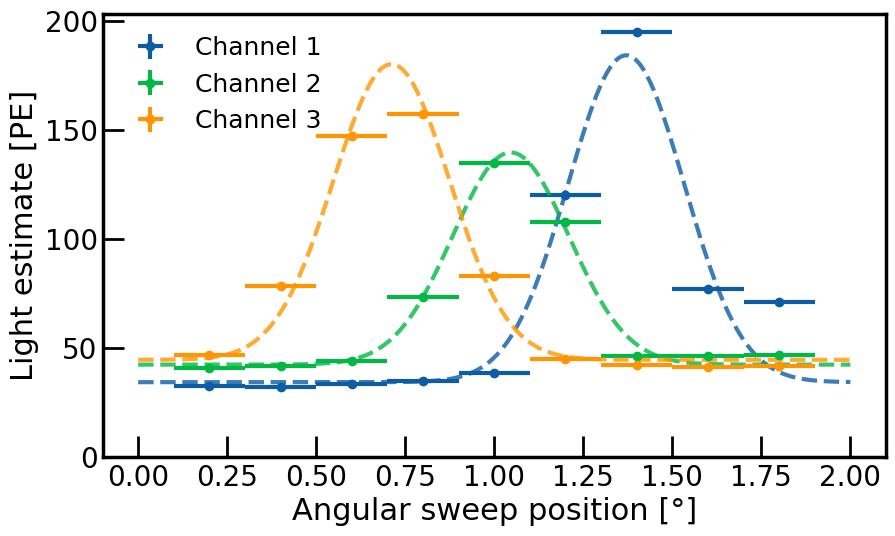

[1022, 1021, 1020, 1019, 1018, 1017, 1016, 1015, 1009] 175
fit results 132.9967569918594 1.4610166575131989 33.6984396157099
fit results 55.285517430614895 1.0426173144770128 46.39895452570829
fit results 74.59909106581257 0.6796155705851793 42.40023519659331
area [66.68380524085242, 27.71983889207563, 37.403553081236005]
175
peak diff -0.4183993430361861 -0.3630017438918335
common width 0.20002735352606393
saving


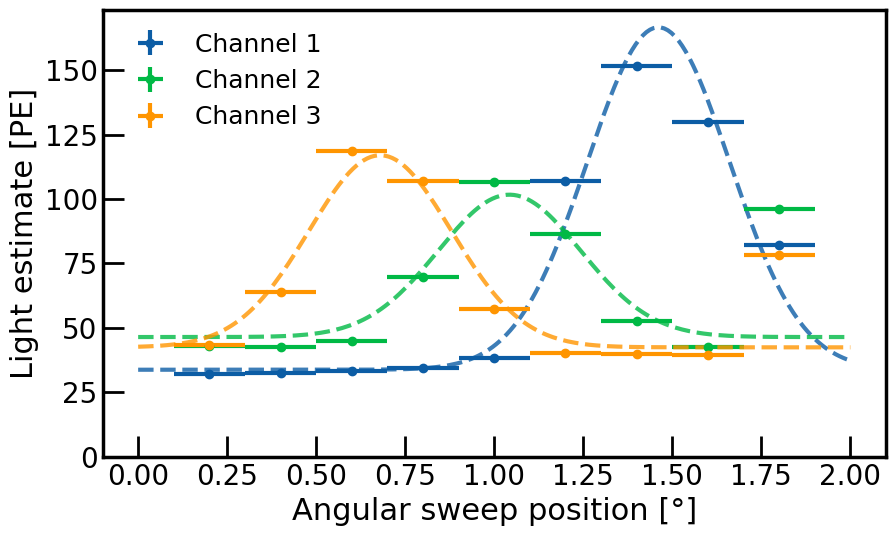

[1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031] 230
fit results 609.0085356989131 1.376436358675575 32.41295397263412
fit results 298.3675950738548 1.0221185117119314 45.4546338027529
fit results 343.27600175466443 0.6724594743774327 43.243026274484414
area [271.0410941073623, 132.7894022407942, 152.77602470646477]
230
peak diff -0.35431784696364366 -0.34965903733449866
common width 0.17755047068691426
saving


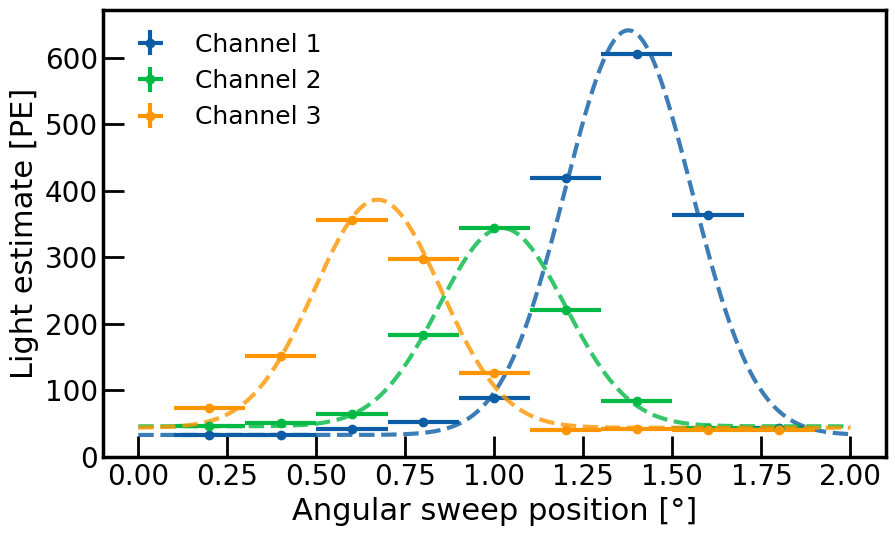

[1040, 1039, 1038, 1037, 1036, 1035, 1034, 1033, 1032] 220
fit results 498.8314686158838 1.4011911754561037 33.678187900539484
fit results 303.02447336233564 1.0546661290294488 45.69749545289221
fit results 310.78668280234723 0.6796204004400491 41.10767688877165
area [210.87070589818273, 128.09734073041218, 131.37865453462447]
220
peak diff -0.34652504642665494 -0.37504572858939966
common width 0.16864461360929095


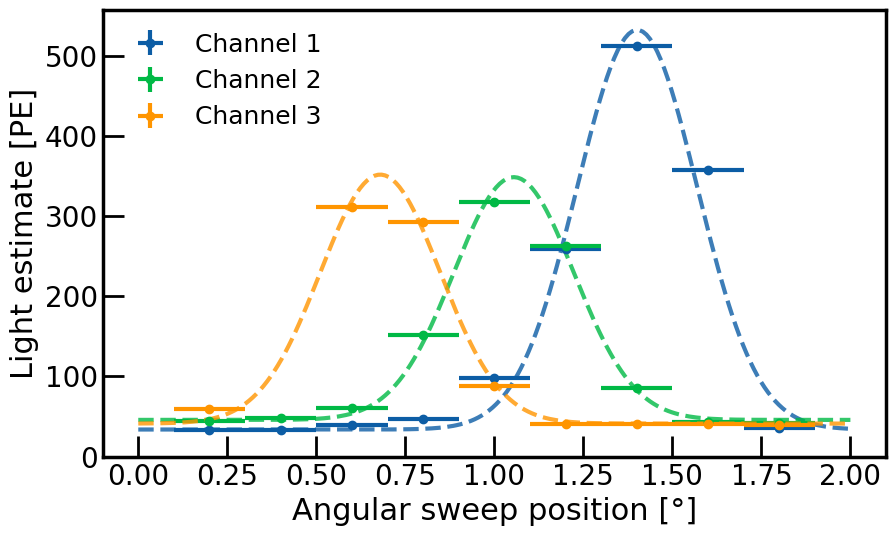

[1041, 1042, 1045, 1044, 1047, 1046, 1052, 1051, 1050] 128
fit results 295.49480593883635 1.3710371881175343 35.068393988977206
fit results 132.683716839738 1.023928382031727 43.04302233339955
fit results 189.56887350701612 0.6160423971262388 36.39645332683772
area [144.3040344492143, 64.795709639832, 92.57541149037134]
128
peak diff -0.3471088060858072 -0.40788598490548833
common width 0.1948223096219583


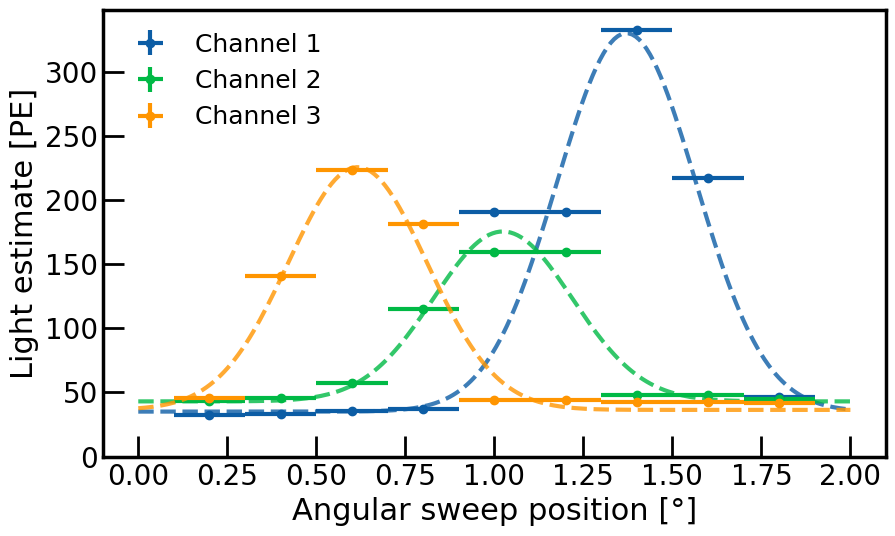

[1061, 1060, 1059, 1058, 1057, 1056, 1055, 1054, 1053] 122
fit results 684.804239486146 1.361042106368882 36.88598116923864
fit results 338.2678887064482 1.0225381384351948 45.86722313362686
fit results 409.00842805194895 0.6633301125752318 47.355583969409345
area [261.59907965104077, 129.2202402653171, 156.24352505205738]
122
peak diff -0.3385039679336872 -0.35920802585996303
common width 0.15239819990777606


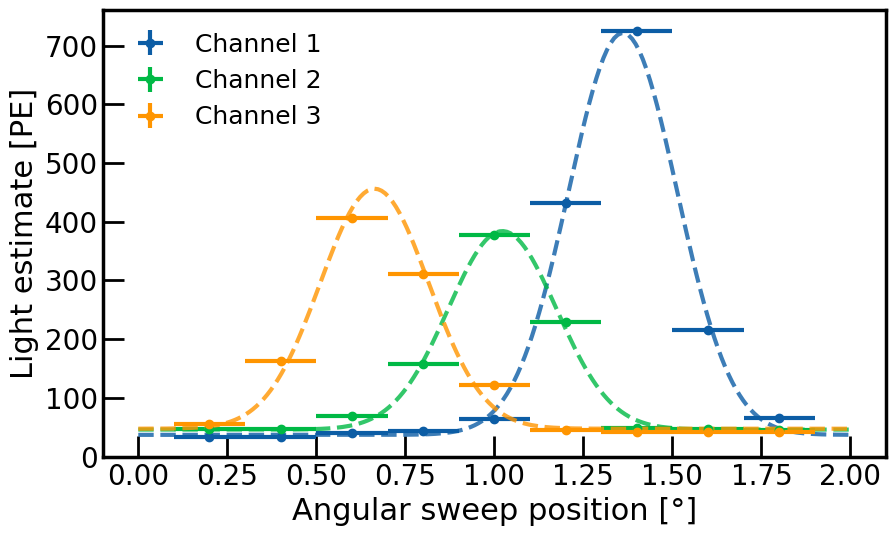

[1062, 1063, 1064, 1065, 1066, 1067, 1069] 138 (run 2)
fit results 174.38785537724837 1.2331387409117767 34.402376897783185
fit results 131.82808919988372 0.8865519654718894 48.47186324054747
fit results 95.14465460759259 0.4050318201173282 49.92111842691498
area [93.06385054995889, 70.35139898386088, 50.77491146315035]
138 (run 2)
peak diff -0.34658677543988725 -0.4815201453545612
common width 0.2128996006116521


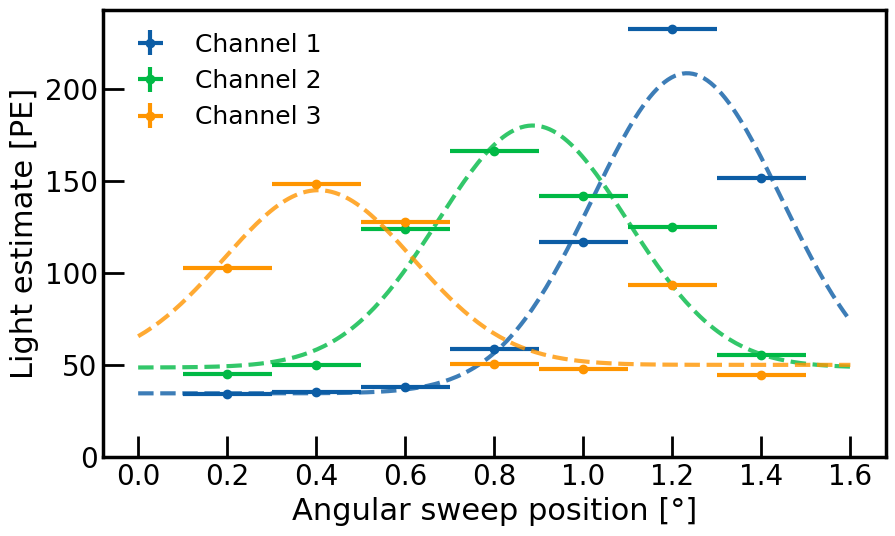

In [ ]:
# Reflectance standard measurements at each wavelength
# Run groups correspond to angular sweep positions (0.2° per step)
# SPE values fixed from gain stability analysis (Block 4)
spe_fixed = [2968, 3381, 2840]

runs = []
runs.append([998,  999,  1000, 1001, 1002, 1003, 1004, 1007, 1008])  # 138 nm (run 1)
runs.append([1022, 1021, 1020, 1019, 1018, 1017, 1016, 1015, 1009])  # 175 nm
runs.append([1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031])  # 230 nm
runs.append([1040, 1039, 1038, 1037, 1036, 1035, 1034, 1033, 1032])  # 220 nm
runs.append([1041, 1042, 1045, 1044, 1047, 1046, 1052, 1051, 1050])  # 128 nm
runs.append([1061, 1060, 1059, 1058, 1057, 1056, 1055, 1054, 1053])  # 122 nm
runs.append([1062, 1063, 1064, 1065, 1066, 1067, 1069])              # 138 nm (run 2)

wavelengths = ['138 (run 1)', '175', '230', '220', '128', '122', '138 (run 2)']

light_estimate_standard, light_es_err_standard, dc_estimate, dc_estimate_err = \
    plot_dataset(runs, wavelengths, run_results, spe_fixed, fit_gaussians=True)

In [ ]:
# Sort results by wavelength for plotting
# Drop the repeated 138 nm run — used as consistency check only
wavelengths = np.array([138, 175, 230, 220, 128, 122], dtype=float)

light_estimate_standard = np.array(light_estimate_standard[:-1])
light_es_err_standard   = np.array(light_es_err_standard[:-1])
dc_estimate             = np.array(dc_estimate[:-1])
dc_estimate_err         = np.array(dc_estimate_err[:-1])

sorted_indices          = np.argsort(wavelengths)[::-1]
wavelengths             = wavelengths[sorted_indices]
light_estimate_standard = light_estimate_standard[sorted_indices]
light_es_err_standard   = light_es_err_standard[sorted_indices]
dc_estimate             = dc_estimate[sorted_indices]
dc_estimate_err         = dc_estimate_err[sorted_indices]

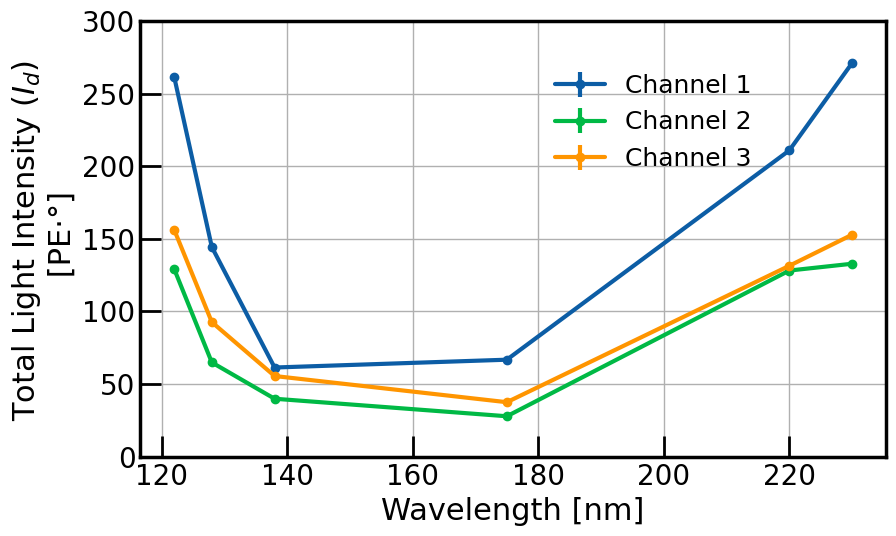

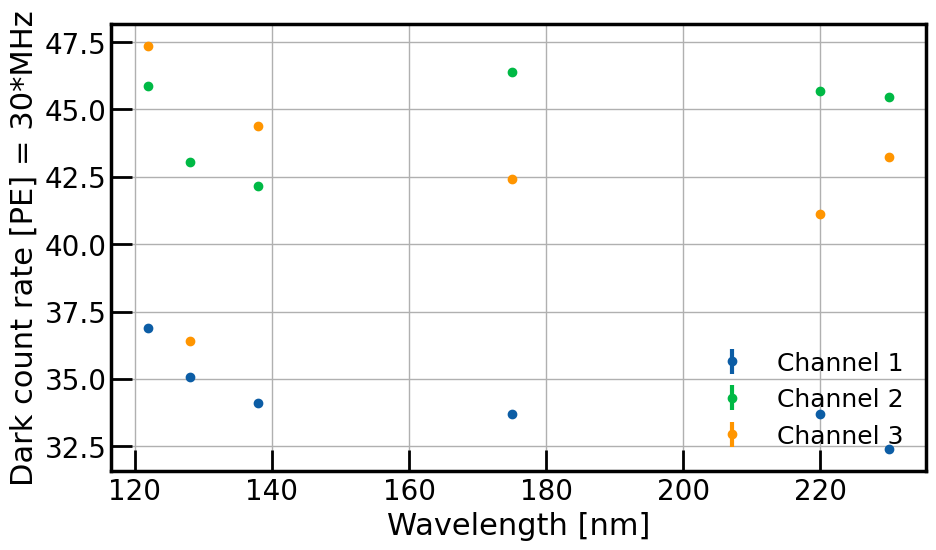

In [ ]:
# Total integrated light yield vs wavelength for the reflectance standard
for ch in range(3):
    plt.errorbar(wavelengths, light_estimate_standard[:, ch],
                 light_es_err_standard[:, ch],
                 fmt='o-', label=f'Channel {ch+1}')
plt.xlabel('Wavelength [nm]', fontsize=22)
plt.ylabel('Total Light Intensity ($I_d$) \n [PE·°]', fontsize=22)
plt.legend(loc='upper right', fontsize=18, bbox_to_anchor=(0.85, 0.93))
plt.grid(True)
plt.ylim(0, 300)
plt.tight_layout()
plt.savefig('reflectance_standard.pdf')
plt.show()

# Dark count rate vs wavelength — cross-check that background is stable
plt.figure(figsize=(10, 6))
for ch in range(3):
    plt.errorbar(wavelengths,
                 30 * np.array(dc_estimate[:, ch]),
                 30 * np.array(dc_estimate_err[:, ch]),
                 fmt='o', label=f'Channel {ch+1}')
plt.xlabel('Wavelength [nm]', fontsize=22)
plt.ylabel('Dark count rate [PE] = 30*MHz', fontsize=22)
plt.legend(loc='lower right', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Instrument Corrections

The raw light yield measured by the SiPMs depends not only on the sample reflectivity but also on the wavelength-dependent response of the instrument itself. Three correction factors are applied:

- **Grating efficiency**: the monochromator grating diffracts light with different efficiency at each wavelength — measured and provided as a calibration file
- **Lamp spectrum**: the deuterium lamp does not emit uniformly across wavelengths — the spectral shape is measured and normalised to unit total flux
- **SiPM quantum efficiency**: the probability of detecting a photon varies with wavelength

These three factors are interpolated to a common wavelength axis and multiplied together to give a total correction factor `F(λ)`. The reflectivity calculation in Block 7 divides out this factor, leaving only the sample-dependent signal.

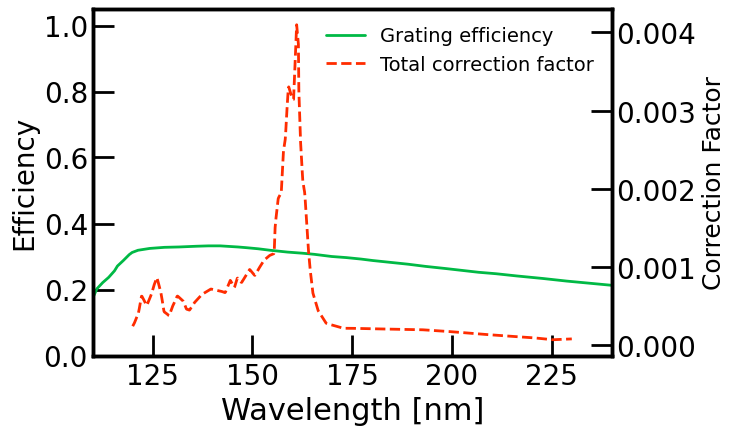

In [ ]:
# Load calibration files
grating = pd.read_csv('/project/vuvsetup/data/GratingReflectivity.csv', delimiter=';')
grating = grating.applymap(lambda x: float(str(x).replace(',', '.')))

sipm = pd.read_csv('/project/vuvsetup/data/SiPMefficiency.csv', delimiter=';')
sipm = sipm.applymap(lambda x: float(str(x).replace(',', '.')))

lamp = pd.read_csv('/project/vuvsetup/data/lamp_spectrum.csv')

# Extract arrays
sipm_wl,    sipm_eff    = sipm.iloc[:, 0].to_numpy(),    sipm.iloc[:, 1].to_numpy()
grating_wl, grating_eff = grating.iloc[:, 0].to_numpy(), grating.iloc[:, 1].to_numpy()
lamp_wl,    lamp_int    = lamp.iloc[:, 1].to_numpy(),    lamp.iloc[:, 2].to_numpy()

# Normalise lamp spectrum to unit total flux
bin_widths = np.diff(lamp_wl, append=lamp_wl[-1])
lamp_int  /= np.sum(lamp_int * bin_widths)

# Interpolate all three to a common wavelength axis
common_wl       = np.linspace(120, 230, 1000)
sipm_interp     = interp1d(sipm_wl,    sipm_eff,    fill_value='extrapolate')
grating_interp  = interp1d(grating_wl, grating_eff, fill_value='extrapolate')
lamp_interp     = interp1d(lamp_wl,    lamp_int,    fill_value='extrapolate')

corrected_intensity = sipm_interp(common_wl) * grating_interp(common_wl) * lamp_interp(common_wl)

# Plot correction factors
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(grating_wl, grating_eff, label='Grating efficiency', color='C1', lw=2)
ax1.set_xlabel('Wavelength [nm]', fontsize=22)
ax1.set_ylabel('Efficiency', fontsize=20)
ax1.set_xlim(110, 240)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(common_wl, corrected_intensity,
         label='Total correction factor', color='C3', lw=2, ls='--')
ax2.set_ylabel('Correction Factor', fontsize=18)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=14, loc='upper right')

plt.tight_layout()
plt.savefig('correction_light.pdf')
plt.show()

## 7. Reflectivity Calculation and Final Result

The absolute reflectivity of the aluminium sample is extracted by comparing its angular sweep light yield to that of the reflectance standard, measured under identical conditions at each wavelength. The standard has a known reflectivity at 230 nm (80.47%), which anchors the absolute scale.

The reflectivity at each wavelength is computed as:
```
R_sample(λ) = R_standard(λ) × [I_sample(λ) / I_standard(λ)] × [F(230) / F(λ)]
```

where `I` is the integrated Gaussian area from the angular sweep and `F(λ)` is the total instrument correction factor from Block 6. A shared calibration ratio accounts for any overall intensity difference between the two measurement sessions.

Uncertainties include statistical errors from the Gaussian fit, the calibration ratio uncertainty, and a 10% systematic uncertainty on the instrument correction factors. Results from all three SiPM channels are combined via a weighted average.

[230. 220. 175. 138. 128. 122.]
[80.47       57.61016068  7.10999055  2.76453299  8.48657684 11.68960093]


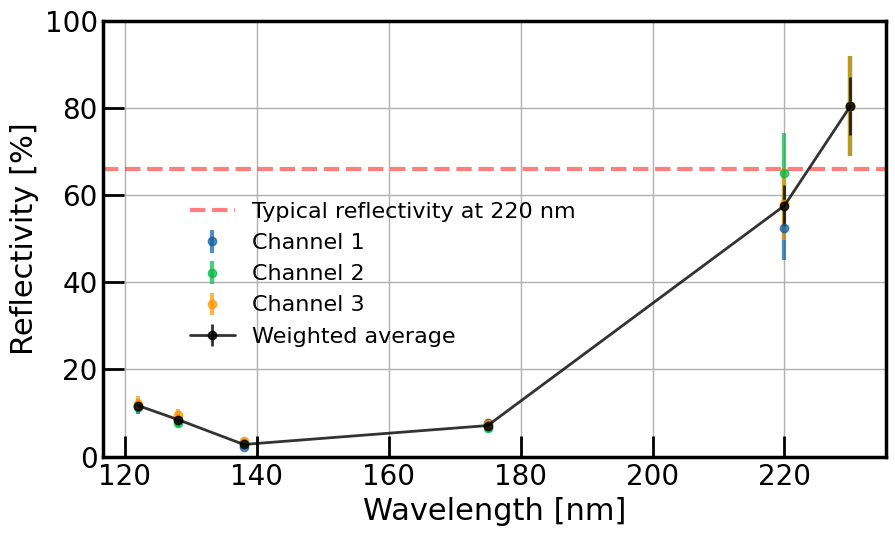

In [ ]:
# Anchor: reflectivity of standard at 230 nm is known to be 80.47%
# All other wavelengths are derived relative to this anchor
rel_interp_err_sq = 0.10**2  # 10% systematic on instrument correction factors

all_r_estimates, all_r_errors = [], []

for ch in range(3):
    val_230     = light_estimate_standard[:, ch][0]
    val_230_err = light_es_err_standard[:, ch][0]
    r_230       = 80.47

    r_estimate, r_err_estimate = [], []
    for k in range(len(wavelengths)):
        wave         = wavelengths[k]
        le           = light_estimate_standard[:, ch][k]
        le_err       = light_es_err_standard[:, ch][k]
        total_factor = sipm_interp(wave) * grating_interp(wave) * lamp_interp(wave)
        total_factor_230 = sipm_interp(230) * grating_interp(230) * lamp_interp(230)

        r_wave = r_230 * le * total_factor_230 / (val_230 * total_factor)
        rel_error_sq = ((le_err / le)**2 + (val_230_err / val_230)**2 +
                        rel_interp_err_sq + rel_interp_err_sq)
        r_estimate.append(r_wave)
        r_err_estimate.append(r_wave * np.sqrt(rel_error_sq))

    all_r_estimates.append(r_estimate)
    all_r_errors.append(r_err_estimate)
    plt.errorbar(wavelengths, r_estimate, yerr=r_err_estimate,
                 alpha=0.7, fmt='o', label=f'Channel {ch+1}')

all_r_estimates = np.array(all_r_estimates)
all_r_errors    = np.array(all_r_errors)
weights         = 1 / all_r_errors**2
weighted_avg    = np.sum(weights * all_r_estimates, axis=0) / np.sum(weights, axis=0)
weighted_err    = np.sqrt(1 / np.sum(weights, axis=0))

plt.errorbar(wavelengths, weighted_avg, yerr=weighted_err,
             fmt='o-', color='black', lw=2, alpha=0.8, label='Weighted average')
plt.axhline(66.03, ls='--', color='red', alpha=0.5, label='Typical reflectivity at 220 nm')
plt.xlabel('Wavelength [nm]', fontsize=22)
plt.ylabel('Reflectivity [%]', fontsize=22)
plt.legend(loc='upper right', fontsize=16, bbox_to_anchor=(0.63, 0.63))
plt.grid(True)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('reflectance_standard_with_avg.pdf')
plt.show()

[1233, 1236, 1237, 1238, 1194, 1205, 1204, 1206, 1207, 1208, 1209, 1210, 1211, 1239, 1240, 1241, 1242] reflectance standard at 175 nm
fit results 509.9538184866893 2.2204608183598875 31.283648163544107
fit results 371.19727433303666 1.8412082594852854 43.210433907857244
fit results 401.428444757483 1.4564918101300373 35.7078427520801
area [198.81636280434768, 144.71916728614184, 156.50543327576239]
reflectance standard at 175 nm
peak diff -0.3792525588746021 -0.3847164493552482
common width 0.1555361491235806
saving


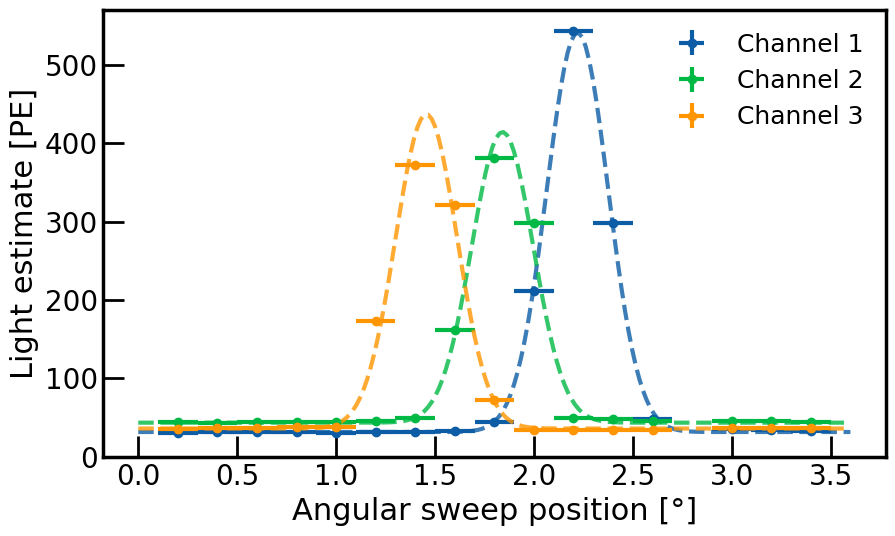

[1232, 1231, 1230, 1229, 1212, 1213, 1214, 1215, 1216, 1217, 1222, 1223, 1224, 1225, 1226, 1227, 1228] 175
fit results 255.4688071842744 2.365685905764237 48.81766436262043
fit results 178.70774914108642 2.0648522877845266 61.094368087445936
fit results 195.70412371578823 1.7308068227955022 55.455654276385026
area [330.4122356048268, 231.13282425521746, 253.11519534114603]
175
peak diff -0.3008336179797104 -0.3340454649890243
common width 0.5159745809970614
saving


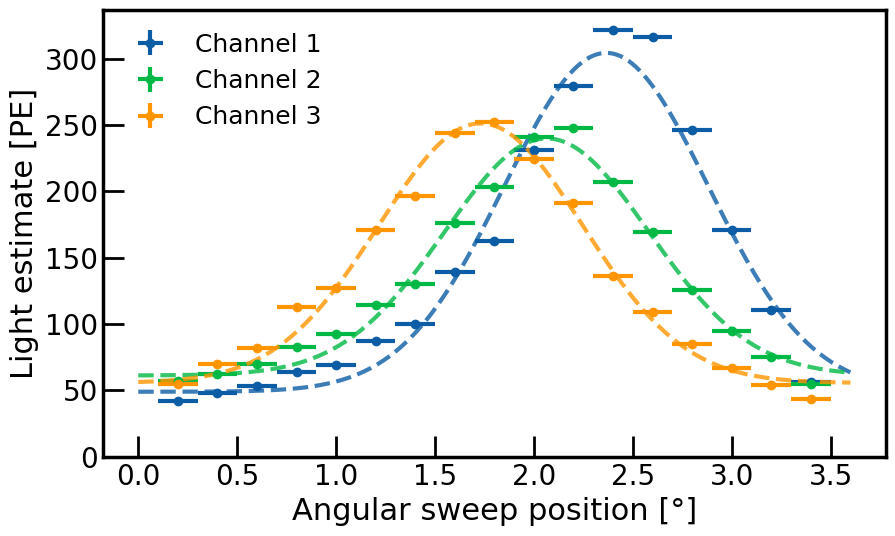

[1243, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1253, 1254, 1255, 1256, 1257, 1258, 1259, 1260, 1261] 138
fit results 349.1451054692486 2.3751172647737775 58.93560953975241
fit results 252.1294611419754 2.077532309359953 71.19050483879636
fit results 244.87241434806734 1.7437628077910639 64.76211185082374
area [443.7519512618555, 320.44825661233847, 311.22478870529966]
138
peak diff -0.29758495541382457 -0.33376950156888907
common width 0.5070425235692795


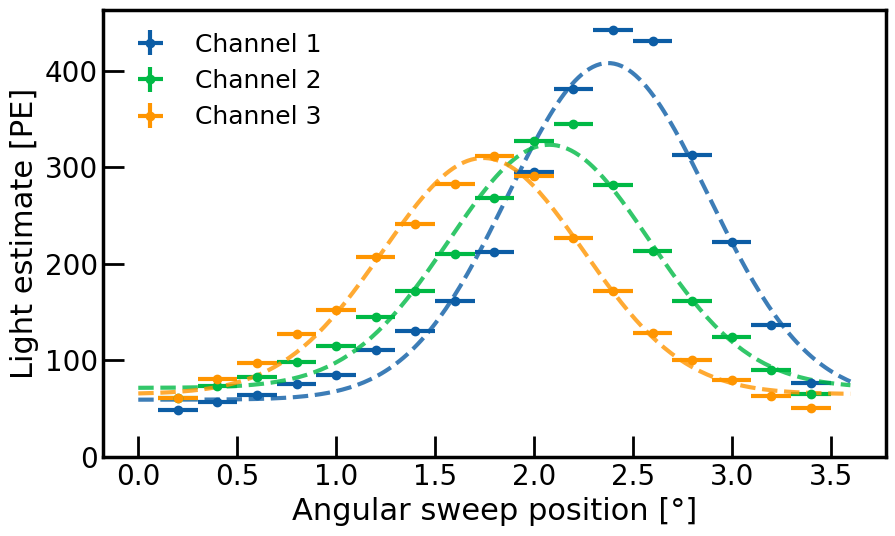

[1280, 1279, 1278, 1277, 1276, 1275, 1274, 1273, 1271, 1270, 1269, 1268, 1267, 1265, 1264, 1263, 1262] 128
fit results 141.55165045770264 2.388098227764192 44.04233136063584
fit results 95.6273243854698 2.091280750537088 56.43466814459457
fit results 90.25211774804757 1.7724140498070595 49.26114845995888
area [175.18948378942676, 118.35186337343688, 111.69931165096236]
128
peak diff -0.29681747722710394 -0.3188667007300283
common width 0.49374551225164187


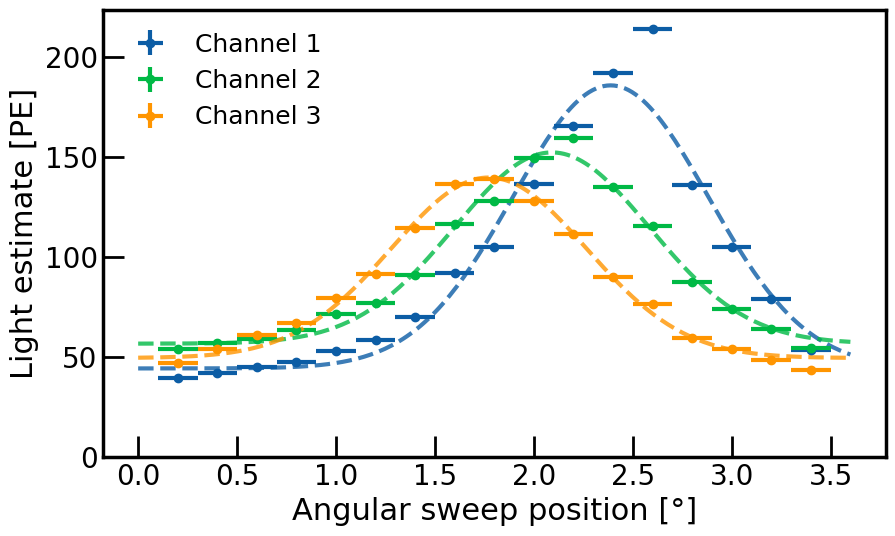

[1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298] 122
fit results 152.7258318468547 2.4561179893994516 46.996288799342146
fit results 81.6546529521975 2.1143389975558398 57.736016883145524
fit results 80.83466562501563 1.7821639158965157 50.88027860863865
area [194.97668466884028, 104.24401247569357, 103.19717967346858]
122
peak diff -0.3417789918436118 -0.3321750816593241
common width 0.5093077069299992


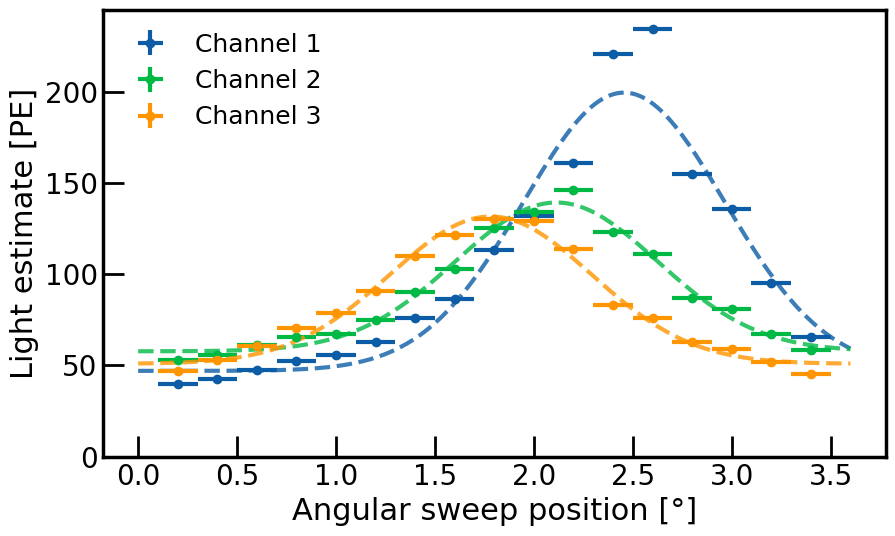

In [ ]:
%store -r sample3

# Aluminium PCB sample — angular sweeps at 122, 128, 138, 175 nm
# First run group is a repeated reflectance standard measurement
# used to cross-calibrate the two measurement sessions
spe_fixed = [2950, 3450, 2840]

runs = []
runs.append([1233,1236,1237,1238,1194,1205,1204,1206,
             1207,1208,1209,1210,1211,1239,1240,1241,1242])  # standard at 175 nm
runs.append([1232,1231,1230,1229,1212,1213,1214,1215,
             1216,1217,1222,1223,1224,1225,1226,1227,1228])  # 175 nm
runs.append([1243,1244,1245,1246,1247,1248,1249,1250,
             1253,1254,1255,1256,1257,1258,1259,1260,1261])  # 138 nm
runs.append([1280,1279,1278,1277,1276,1275,1274,1273,
             1271,1270,1269,1268,1267,1265,1264,1263,1262])  # 128 nm
runs.append([1282,1283,1284,1285,1286,1287,1288,1289,
             1290,1291,1292,1293,1294,1295,1296,1297,1298])  # 122 nm

wavelengths_sample = ['reflectance standard at 175 nm', '175', '138', '128', '122']

light_estimate, light_es_err, dc_estimate, dc_estimate_err = \
    plot_dataset(runs, wavelengths_sample, sample3, spe_fixed, fit_gaussians=True)

[230. 220. 175. 138. 128. 122.]
['reflectance standard at 175 nm', '175', '138', '128', '122']
[80.47       57.61016068  7.10999055  2.76453299  8.48657684 11.68960093]
[6.57064397 4.72202588 0.58243103 0.23009167 0.69565234 0.95480161]
Shared calibration:
  l0_avg = 166.68 ± 0.20, orl0_avg = 43.94 ± 0.07
  ratio = 3.794 ± 0.007
[175, 138, 128, 122]
[11.43399127  4.84582463  2.95550222  2.24179548]
[0.55406366 0.23586307 0.14229945 0.10623507]


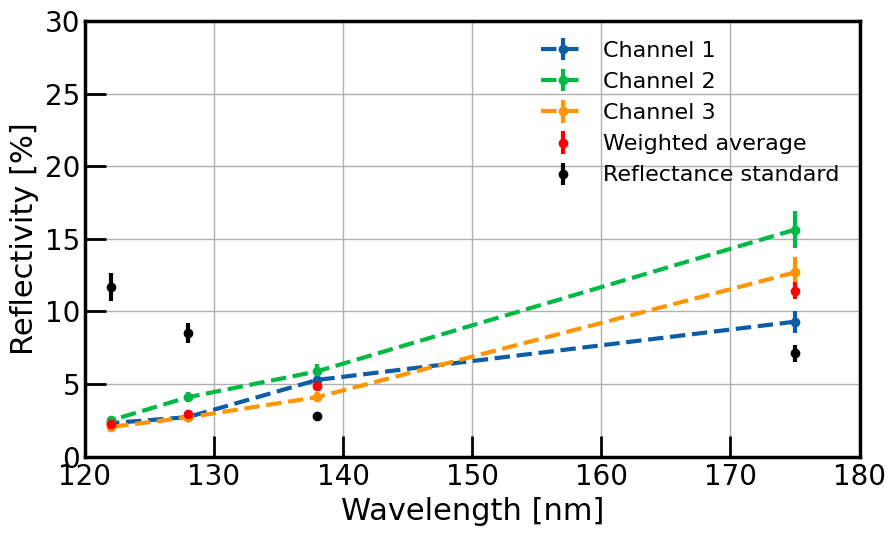

In [ ]:
refl_standard     = weighted_avg
refl_standard_err = weighted_err

print(wavelengths)
print(wavelengths_sample)
print(refl_standard)
print(refl_standard_err)

# Shared calibration ratio: average across all three channels
# l0 = standard measured in sample session at 175 nm
# or_l0 = standard measured in original session at 175 nm (third run after flips)
l0_list, lerr0_list, orl0_list, orlerr0_list = [], [], [], []
for j in range(3):
    l0_list.append(light_estimate[0][j])
    lerr0_list.append(light_es_err[0][j])
    orl0_list.append(light_estimate_standard[2][j])
    orlerr0_list.append(light_es_err_standard[2][j])

l0_avg   = np.mean(l0_list)
l0_err   = np.sqrt(np.sum(np.array(lerr0_list)**2)) / 3
orl0_avg = np.mean(orl0_list)
orl0_err = np.sqrt(np.sum(np.array(orlerr0_list)**2)) / 3
ratio    = l0_avg / orl0_avg
dratio   = ratio * np.sqrt((l0_err / l0_avg)**2 + (orl0_err / orl0_avg)**2)

print(f'Calibration ratio: {ratio:.3f} +/- {dratio:.3f}')

# Per-channel reflectivity with full error propagation
all_r_estimates, all_r_errors = [], []
for j in range(3):
    res, res_err, x_val = [], [], []
    for k in range(1, 5):
        x_val.append(int(wavelengths_sample[k]))
        l_sample         = light_estimate[k][j]
        lerr_sample      = light_es_err[k][j]
        or_l_standard    = light_estimate_standard[1 + k][j]
        or_lerr_standard = light_es_err_standard[1 + k][j]
        refl_ref         = refl_standard[1 + k]
        refl_ref_err     = refl_standard_err[1 + k]

        denom     = ratio * or_l_standard
        denom_err = denom * np.sqrt((dratio / ratio)**2 +
                                    (or_lerr_standard / or_l_standard)**2)
        refl      = refl_ref * l_sample / denom
        d_refl    = refl * np.sqrt((refl_ref_err / refl_ref)**2 +
                                   (lerr_sample / l_sample)**2 +
                                   (denom_err / denom)**2)
        res.append(refl)
        res_err.append(d_refl)

    plt.errorbar(x_val, res, yerr=res_err, fmt='o--', label=f'Channel {j+1}')
    all_r_estimates.append(res)
    all_r_errors.append(res_err)

# Weighted average across channels
all_r_estimates     = np.array(all_r_estimates)
all_r_errors        = np.array(all_r_errors)
weights             = 1 / all_r_errors**2
weighted_avg_sample = np.sum(weights * all_r_estimates, axis=0) / np.sum(weights, axis=0)
weighted_err_sample = np.sqrt(1 / np.sum(weights, axis=0))

print(x_val)
print(weighted_avg_sample)
print(weighted_err_sample)

plt.errorbar(x_val, weighted_avg_sample, weighted_err_sample,
             color='r', fmt='o', label='Weighted average')
plt.errorbar(wavelengths, refl_standard, refl_standard_err,
             color='k', fmt='o', label='Reflectance standard')
plt.xlabel('Wavelength [nm]', fontsize=22)
plt.ylabel('Reflectivity [%]', fontsize=22)
plt.legend(loc='upper right', fontsize=16)
plt.grid(True)
plt.ylim(0, 30)
plt.xlim(120, 180)
plt.tight_layout()
plt.savefig('reflectance_final.pdf')
plt.show()